<a href="https://colab.research.google.com/github/farahnahh/NorthStar-Urban-Mobility-Analytics/blob/main/notebooks/03_Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics

# Python Integrated Operational Intelligence Analytics

## Objective

This notebook investigates integrated operational intelligence across NorthStar Urban Mobility and Logistics using Python-based analytical techniques.

The analysis focuses on connecting fragmented operational datasets to identify hidden relationships between delivery performance, customer complaints, operational disruptions, workforce behaviour, and logistics efficiency.

The investigation aims to uncover systemic operational inefficiencies, root-cause patterns, operational risk indicators, and management-level intelligence capable of supporting operational optimisation and strategic decision-making.

---

# Python Analytical Environment Setup

The following section imports the analytical libraries required for integrated operational intelligence analysis, data integration, KPI generation, operational risk investigation, and management-focused analytical modelling across the NorthStar environment.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Python analytical environment successfully initialised.")

Python analytical environment successfully initialised.


---

# Loading Integrated NorthStar Operational Datasets

The following section loads fragmented operational datasets into the Python analytical environment to support integrated operational intelligence investigation across deliveries, complaints, incidents, workforce operations, and logistics performance.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define dataset path
base_path = "/content/drive/MyDrive/NorthStar_Datasets/raw_data/"

# Load datasets
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
incidents = pd.read_csv(base_path + "incidents.csv")
orders = pd.read_csv(base_path + "orders.csv")
drivers = pd.read_csv(base_path + "drivers.csv")
hubs = pd.read_csv(base_path + "hubs.csv")

# Display dataset dimensions
print("Deliveries Dataset:", deliveries.shape)
print("Complaints Dataset:", complaints.shape)
print("Incidents Dataset:", incidents.shape)
print("Orders Dataset:", orders.shape)
print("Drivers Dataset:", drivers.shape)
print("Hubs Dataset:", hubs.shape)

Mounted at /content/drive
Deliveries Dataset: (950, 13)
Complaints Dataset: (320, 10)
Incidents Dataset: (280, 7)
Orders Dataset: (1250, 11)
Drivers Dataset: (170, 8)
Hubs Dataset: (8, 5)


---

# Integrated Operational Intelligence Investigation

The following analysis integrates operational delivery records, customer complaint activity, and operational incident data to identify hidden relationships affecting logistics performance, customer satisfaction, and operational reliability across the NorthStar environment.

In [ ]:
# Integrate deliveries with complaints
delivery_complaint_analysis = deliveries.merge(
    complaints,
    on='order_id',
    how='left'
)

# Integrate incidents
delivery_complaint_analysis = delivery_complaint_analysis.merge(
    incidents,
    on='delivery_id',
    how='left'
)

# Display dataset preview
delivery_complaint_analysis.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,complaint_id,customer_id,complaint_type,channel,severity_x,created_at,status,resolution_days,compensation_amount,incident_id,incident_type,reported_at,severity_y,resolution_status,resolved_hours
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I0180,ProofMissing,2024-06-18 11:38:00,High,Open,5.6
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# Operational Intelligence KPI Generation

The following analysis generates integrated operational intelligence indicators capable of identifying logistics inefficiencies, operational risk exposure, customer dissatisfaction patterns, and delivery performance instability across the NorthStar operational environment.

In [ ]:
# Generate operational intelligence metrics

delivery_complaint_analysis['delivery_failure_flag'] = np.where(
    delivery_complaint_analysis['delivery_status'] == 'Failed',
    1,
    0
)

delivery_complaint_analysis['delivery_delay_flag'] = np.where(
    delivery_complaint_analysis['delivery_status'] == 'Delayed',
    1,
    0
)

delivery_complaint_analysis['complaint_flag'] = np.where(
    delivery_complaint_analysis['complaint_id'].notna(),
    1,
    0
)

# Use merged severity column
delivery_complaint_analysis['high_severity_incident_flag'] = np.where(
    delivery_complaint_analysis['severity_y'].isin(['High', 'Critical']),
    1,
    0
)

# Generate operational risk score
delivery_complaint_analysis['operational_risk_score'] = (
    delivery_complaint_analysis['delivery_failure_flag'] * 3
    +
    delivery_complaint_analysis['delivery_delay_flag'] * 2
    +
    delivery_complaint_analysis['complaint_flag'] * 2
    +
    delivery_complaint_analysis['high_severity_incident_flag'] * 3
)

# Display generated intelligence metrics
delivery_complaint_analysis[
    [
        'delivery_id',
        'delivery_status',
        'complaint_flag',
        'high_severity_incident_flag',
        'operational_risk_score'
    ]
].head()

,delivery_id,delivery_status,complaint_flag,high_severity_incident_flag,operational_risk_score
0,DL00001,Failed,0,1,6
1,DL00002,OnTime,0,0,0
2,DL00003,OnTime,0,0,0
3,DL00004,Delayed,0,0,2
4,DL00005,OnTime,0,0,0


---

# Operational Risk Distribution Investigation

The following analysis evaluates operational risk distribution across delivery outcomes to identify which operational conditions contribute most significantly to elevated logistics instability and service disruption risk.

In [ ]:
# Analyse operational risk by delivery outcome

risk_distribution = (
    delivery_complaint_analysis
    .groupby('delivery_status')['operational_risk_score']
    .mean()
    .reset_index()
)

risk_distribution = risk_distribution.sort_values(
    by='operational_risk_score',
    ascending=False
)

print(risk_distribution)

  delivery_status  operational_risk_score
1          Failed                3.928058
0         Delayed                2.771429
2          OnTime                0.730594


---

# Complaint and Operational Risk Relationship Investigation

The following analysis investigates the relationship between customer complaint activity and operational risk exposure to determine whether customer dissatisfaction is associated with elevated operational instability across the NorthStar logistics environment.

In [ ]:
# Analyse operational risk by complaint activity

complaint_risk_analysis = (
    delivery_complaint_analysis
    .groupby('complaint_flag')['operational_risk_score']
    .mean()
    .reset_index()
)

# Rename categories for readability
complaint_risk_analysis['complaint_flag'] = (
    complaint_risk_analysis['complaint_flag']
    .map({
        0: 'No Complaint',
        1: 'Complaint Logged'
    })
)

print(complaint_risk_analysis)

     complaint_flag  operational_risk_score
0      No Complaint                1.139687
1  Complaint Logged                3.062500


---

# Hub Operational Risk Investigation

The following analysis investigates operational risk concentration across logistics hubs to identify high-risk operational locations contributing disproportionately to delivery instability, service disruption, and operational inefficiency within the NorthStar environment.

In [ ]:
# Analyse operational risk concentration by hub

hub_risk_analysis = (
    delivery_complaint_analysis
    .groupby('hub_id')['operational_risk_score']
    .mean()
    .reset_index()
)

# Sort hubs by highest operational risk
hub_risk_analysis = hub_risk_analysis.sort_values(
    by='operational_risk_score',
    ascending=False
)

print(hub_risk_analysis)

  hub_id  operational_risk_score
4    H05                1.778689
7    H08                1.753623
6    H07                1.743802
5    H06                1.699115
2    H03                1.531250
1    H02                1.459459
3    H04                1.446154
0    H01                1.398601


---

# Driver Operational Instability Investigation

The following analysis investigates operational risk exposure across drivers to identify workforce-related instability patterns contributing to delivery disruption, failed logistics execution, and inconsistent operational performance within the NorthStar environment.

In [ ]:
# Analyse operational risk exposure across drivers

driver_risk_analysis = (
    delivery_complaint_analysis
    .groupby('driver_id')['operational_risk_score']
    .mean()
    .reset_index()
)

# Sort drivers by highest operational risk
driver_risk_analysis = driver_risk_analysis.sort_values(
    by='operational_risk_score',
    ascending=False
)

# Display highest-risk drivers
print(driver_risk_analysis.head(10))

    driver_id  operational_risk_score
111      D112                4.500000
62       D063                4.333333
41       D042                4.250000
169      D170                4.000000
50       D051                4.000000
61       D062                3.666667
102      D103                3.500000
110      D111                3.500000
135      D136                3.500000
132      D133                3.307692


---

# Incident Correlation and Operational Instability Investigation

The following analysis investigates the relationship between operational incident severity and operational risk exposure to evaluate whether high-severity incidents contribute significantly to delivery instability, service disruption, and logistics inefficiency within the NorthStar environment.

In [ ]:
# Analyse operational risk by incident severity classification

incident_risk_analysis = (
    delivery_complaint_analysis
    .groupby('high_severity_incident_flag')['operational_risk_score']
    .mean()
    .reset_index()
)

# Rename categories for readability
incident_risk_analysis['high_severity_incident_flag'] = (
    incident_risk_analysis['high_severity_incident_flag']
    .map({
        0: 'Low/Medium Severity',
        1: 'High/Critical Severity'
    })
)

print(incident_risk_analysis)

  high_severity_incident_flag  operational_risk_score
0         Low/Medium Severity                1.300330
1      High/Critical Severity                4.391753


---

# Operational Anomaly Detection Investigation

The following analysis identifies unusually high-risk operational records within the NorthStar logistics environment to investigate abnormal service disruption patterns, operational escalation anomalies, and severe logistics instability indicators across integrated operational systems.

In [ ]:
# Detect unusually high-risk operational records

operational_anomalies = delivery_complaint_analysis[
    delivery_complaint_analysis['operational_risk_score'] >= 6
]

# Display anomaly records
operational_anomalies[
    [
        'delivery_id',
        'delivery_status',
        'complaint_flag',
        'high_severity_incident_flag',
        'operational_risk_score'
    ]
].head(10)

,delivery_id,delivery_status,complaint_flag,high_severity_incident_flag,operational_risk_score
0,DL00001,Failed,0,1,6
70,DL00068,Failed,0,1,6
141,DL00135,Failed,0,1,6
193,DL00187,Failed,0,1,6
195,DL00189,Failed,1,1,8
215,DL00208,Failed,0,1,6
322,DL00306,Delayed,1,1,7
341,DL00324,Failed,1,1,8
398,DL00378,Failed,0,1,6
496,DL00469,Delayed,1,1,7


---

# Delivery Failure Concentration Investigation

The following analysis investigates the concentration of failed deliveries across operational conditions to identify recurring instability patterns and operational factors contributing disproportionately to failed logistics execution within the NorthStar environment.

In [ ]:
# Analyse failed delivery concentration by operational conditions

failure_condition_analysis = (
    delivery_complaint_analysis
    .groupby(
        [
            'complaint_flag',
            'high_severity_incident_flag'
        ]
    )['delivery_failure_flag']
    .mean()
    .reset_index()
)

# Rename categories for readability
failure_condition_analysis['complaint_flag'] = (
    failure_condition_analysis['complaint_flag']
    .map({
        0: 'No Complaint',
        1: 'Complaint Logged'
    })
)

failure_condition_analysis['high_severity_incident_flag'] = (
    failure_condition_analysis['high_severity_incident_flag']
    .map({
        0: 'Low/Medium Severity',
        1: 'High/Critical Severity'
    })
)

print(failure_condition_analysis)

     complaint_flag high_severity_incident_flag  delivery_failure_flag
0      No Complaint         Low/Medium Severity               0.129738
1      No Complaint      High/Critical Severity               0.175000
2  Complaint Logged         Low/Medium Severity               0.139013
3  Complaint Logged      High/Critical Severity               0.294118


---

# Management-Focused Operational Intelligence Metrics Investigation

The following analysis generates management-focused operational intelligence metrics to evaluate comparative operational performance, logistics instability exposure, customer dissatisfaction concentration, and delivery reliability across the NorthStar operational environment.

In [ ]:
# Generate hub-level operational intelligence metrics

hub_intelligence_metrics = (
    delivery_complaint_analysis
    .groupby('hub_id')
    .agg(
        total_deliveries=('delivery_id', 'count'),
        avg_operational_risk=('operational_risk_score', 'mean'),
        complaint_ratio=('complaint_flag', 'mean'),
        failure_ratio=('delivery_failure_flag', 'mean')
    )
    .reset_index()
)

# Round metrics for readability
hub_intelligence_metrics[
    [
        'avg_operational_risk',
        'complaint_ratio',
        'failure_ratio'
    ]
] = hub_intelligence_metrics[
    [
        'avg_operational_risk',
        'complaint_ratio',
        'failure_ratio'
    ]
].round(3)

# Sort by highest operational risk
hub_intelligence_metrics = (
    hub_intelligence_metrics
    .sort_values(
        by='avg_operational_risk',
        ascending=False
    )
)

print(hub_intelligence_metrics)

  hub_id  total_deliveries  avg_operational_risk  complaint_ratio  \
4    H05               122                 1.779            0.246   
7    H08               138                 1.754            0.261   
6    H07               121                 1.744            0.281   
5    H06               113                 1.699            0.230   
2    H03               128                 1.531            0.281   
1    H02               111                 1.459            0.162   
3    H04               130                 1.446            0.215   
0    H01               143                 1.399            0.224   

   failure_ratio  
4          0.197  
7          0.196  
6          0.132  
5          0.142  
2          0.094  
1          0.090  
3          0.123  
0          0.126  


---

# Operational Intelligence Visualisation Investigation

The following visual analysis presents comparative operational risk exposure across NorthStar logistics hubs to support management-level operational visibility, performance comparison, and identification of high-risk logistics locations requiring operational intervention.

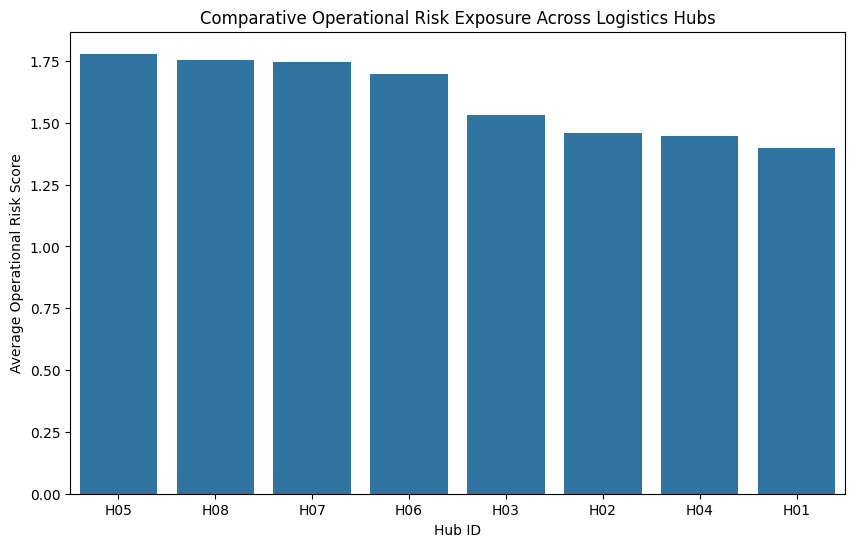

In [ ]:
# Visualise comparative hub operational risk exposure

plt.figure(figsize=(10,6))

sns.barplot(
    data=hub_intelligence_metrics,
    x='hub_id',
    y='avg_operational_risk'
)

plt.title('Comparative Operational Risk Exposure Across Logistics Hubs')
plt.xlabel('Hub ID')
plt.ylabel('Average Operational Risk Score')

plt.show()

---

# Strategic Operational Intelligence Interpretation

The integrated Python operational intelligence investigation revealed that operational instability within the NorthStar environment is systemic, interconnected, and concentrated across specific operational conditions, logistics hubs, workforce segments, and incident escalation scenarios.

The analysis demonstrated that customer complaints, failed deliveries, severe operational incidents, and elevated logistics risk exposure are strongly interconnected rather than isolated operational events. Integrated analytics identified disproportionately high operational instability across specific hubs and workforce segments, while anomaly detection revealed escalation-heavy disruption cases involving compounded operational failures.

These findings support the conclusion that NorthStar’s operational inefficiencies are primarily driven by fragmented operational visibility, disconnected analytical systems, and insufficient integration between delivery operations, incident management, and customer-service intelligence. The investigation further demonstrates the value of integrated operational intelligence modelling for supporting management-level operational visibility, targeted intervention, and strategic logistics optimisation.